# Galaxy Image Simulation — Part 1: Theory and Interactive Explorer
## From pixels to physical parameters  
**Part 2 (pipeline):** `galaxy_image_simulation_part2.ipynb`

**Simulator:** GalSim — [https://galsim-developers.github.io/GalSim/_build/html/index.html](https://galsim-developers.github.io/GalSim/_build/html/index.html)  
**Detection & fitting:** photutils — [https://photutils.readthedocs.io/en/stable/](https://photutils.readthedocs.io/en/stable/)  
**Profile model:** `astropy.modeling.models.Sersic2D`  
**Reference (GalSim):** Rowe et al. (2015), Astronomy and Computing, 10, 121 — [arXiv:1407.7676](https://arxiv.org/abs/1407.7676)  
**Reference (GALFIT):** Peng et al. (2002), AJ 124, 266 — [arXiv:astro-ph/0204182](https://arxiv.org/abs/astro-ph/0204182)  
**Reference (Sérsic profile):** Sérsic (1963), Boletin de la Asociacion Argentina de Astronomia, 6, 41

---

## Learning objectives

After this tutorial you will be able to:
1. Describe the **Sérsic surface-brightness profile** and its special cases (exponential disk, de Vaucouleurs elliptical).
2. Explain how **atmospheric and instrumental blurring** (the PSF) smears a galaxy image, and why convolution is the right mathematical description.
3. Understand the **noise budget** of a real observation: photon shot noise, sky background, and read noise.
4. Use **GalSim** to simulate a realistic multi-galaxy image field.
5. Detect sources with **photutils** background subtraction and segmentation.
6. Fit a **2-D Sérsic model** to each detected galaxy and recover morphological parameters.
7. Quantify **parameter recovery** (bias and scatter) as a function of signal-to-noise ratio.

---

## 1. Galaxy Surface-Brightness Profiles

### 1.1 The Sérsic profile

The **surface brightness** $I$ of a galaxy is the flux per solid angle (e.g. in units of mag arcsec$^{-2}$ or photons s$^{-1}$ arcsec$^{-2}$). Empirically, nearly all galaxy profiles are well described by the **Sérsic (1963) law**:

$$\boxed{I(r) = I_e \exp\!\left\{-b_n\!\left[\left(\frac{r}{r_e}\right)^{1/n} - 1\right]\right\}}$$

| Symbol | Name | Typical values |
|--------|------|----------------|
| $r$ | Projected radius from centre | 0 → ∞ |
| $r_e$ | Effective (half-light) radius | 0.1–10 arcsec |
| $I_e$ | Surface brightness at $r_e$ | — |
| $n$ | Sérsic index (shape) | 0.5–10 |
| $b_n$ | Normalisation constant | $\approx 2n - 0.327$ |

**Why $b_n$?** The constant $b_n$ is chosen so that $r_e$ encloses exactly half the total luminosity. The exact value solves
$$\Gamma(2n) = 2\,\gamma(2n,\, b_n),$$
where $\Gamma$ is the complete gamma function and $\gamma$ the lower incomplete gamma function. The approximation $b_n \approx 2n - 0.327$ (Graham & Driver 2005, Eq. 9) is accurate to ~1% for $n \geq 1$. The error grows to ~6% at $n = 0.5$, so for $n < 1$ the exact numerical solution (e.g. `scipy.special.gammaincinv(2*n, 0.5)`) should be used. For large $n$ the asymptotic form $b_n \approx 2n - 1/3$ is accurate to 0.1%.

### 1.2 Special cases

- **$n = 1$ — Exponential profile:** $I(r) = I_e\,e^{-b_1(r/r_e - 1)}$, with $b_1 \approx 1.678$.  
  Describes **late-type disk galaxies** (spirals, irregulars). The luminosity decreases exponentially with radius, analogous to the thin stellar disk of the Milky Way.

- **$n = 4$ — de Vaucouleurs (1948) profile:** Proposed before Sérsic's generalisation, with $b_4 \approx 7.67$.  
  Describes **early-type elliptical galaxies** and classical bulges. It has a bright, compact core and extended low-surface-brightness wings — very different from the smooth exponential decline of a disk.

- **$n < 1$:** Flatter central core than exponential (dwarf and irregular galaxies).
- **$n > 4$:** Very concentrated profile (massive compact ellipticals, some bulges).

### 1.3 Elliptical isophotes

Real galaxies are not round. The radius $r$ is replaced by an **elliptical radius**:
$$\tilde{r}(x, y) = \sqrt{x'^2 + \left(\frac{y'}{q}\right)^2}$$
where $(x', y')$ are coordinates **rotated by the position angle** PA (measured east of north), and $q = b/a \in (0, 1]$ is the **axis ratio** ($q = 1$ is round, $q \to 0$ is edge-on disk).

Alternatively, the shape is described by two **ellipticity components**:
$$e_1 = \frac{1-q}{1+q}\cos(2\,\text{PA}), \qquad e_2 = \frac{1-q}{1+q}\sin(2\,\text{PA})$$
with total ellipticity $|e| = \sqrt{e_1^2 + e_2^2} = (1-q)/(1+q)$.

### 1.4 Total flux

Integrating $I(\tilde{r})$ over the elliptical plane gives the total flux (Graham & Driver 2005, Eq. 2):
$$F_\text{tot} = 2\pi\, I_e\, r_e^2\, q\, \frac{n\, e^{b_n}}{b_n^{2n}}\, \Gamma(2n)$$

This follows from the substitution $t = (r/r_e)^{1/n}$ in the radial integral, recognising the integral over $e^{-b_n t} t^{2n-1}$ as $\Gamma(2n)/b_n^{2n}$. This is why $r_e$, $n$, and $I_e$ (or equivalently the total magnitude) are the three key parameters to recover when fitting a galaxy.

---

## 2. The Point Spread Function and Convolution

### 2.1 What is the PSF?

A **point source** (a star infinitely far away) should in principle appear as a single point on the detector. In reality, turbulence in the Earth's atmosphere (**seeing**) and diffraction by the telescope optics **spread** the light over several pixels. The resulting image of a point source is called the **Point Spread Function (PSF)**.

For a ground-based telescope with **Gaussian seeing** (a standard first-order approximation):
$$\text{PSF}(x, y) = \frac{1}{2\pi\sigma^2}\exp\!\left(-\frac{x^2 + y^2}{2\sigma^2}\right)$$

The width is usually quoted as the **Full Width at Half Maximum (FWHM)**:
$$\text{FWHM} = 2\sqrt{2\ln 2}\;\sigma \approx 2.355\;\sigma$$

Typical ground-based seeing: FWHM $\approx 0.5''$–$2''$ (best sites: Mauna Kea, Cerro Paranal $\sim 0.4''$–$0.8''$). Space telescopes remove the atmosphere entirely: HST has FWHM $\approx 0.07''$–$0.14''$ (depending on instrument and filter wavelength); JWST achieves FWHM $\approx 0.03''$–$0.12''$ (from short near-IR at 0.6 μm to mid-IR at 4 μm, set by diffraction from its 6.5 m mirror).

> **Note:** Real PSFs are not perfectly Gaussian. In practice they are measured from bright, unsaturated stars in the science field and modelled empirically (e.g. Moffat profiles, or with the PSFEx software).

### 2.2 Convolution theorem

The observed image is the **convolution** of the true sky brightness with the PSF:
$$I_\text{obs}(x, y) = (I_\text{true} * \text{PSF})(x, y) = \int\!\int I_\text{true}(x', y')\,\text{PSF}(x-x', y-y')\,dx'\,dy'$$

In Fourier space, convolution becomes **multiplication**:
$$\hat{I}_\text{obs}(u, v) = \hat{I}_\text{true}(u, v)\cdot\hat{\text{PSF}}(u, v)$$
This is computationally efficient (use `numpy.fft`) and explains why recovering $I_\text{true}$ from $I_\text{obs}$ (deconvolution) is difficult: dividing by $\hat{\text{PSF}}$ amplifies noise at spatial frequencies where $|\hat{\text{PSF}}| \to 0$.

### 2.3 Effect on morphological parameters

PSF convolution **broadens** the observed profile and makes the galaxy look larger and rounder. If the galaxy's intrinsic half-light radius is comparable to or smaller than the PSF (unresolved), all morphological information is lost. For resolved galaxies:
- **$r_e$ is overestimated** if the PSF is not accounted for in the fit.
- **$n$ is biased toward lower values** (the convolved core looks shallower than the true profile).

This is why fitting must be done in **image space**: convolve the model with the PSF, then compare to the data — not by fitting the 1D radial profile directly.

---

## 3. Image Noise

### 3.1 Photon shot noise

Photons arrive randomly. If on average $\lambda$ photons hit a pixel in an exposure, the actual count follows a **Poisson distribution** $P(k; \lambda) = e^{-\lambda}\lambda^k / k!$ with mean $\lambda$ and variance $\lambda$.

For large $\lambda$ (typically $\lambda > 20$), the Poisson distribution is well approximated by a Gaussian with $\sigma = \sqrt{\lambda}$, so:
$$\sigma_\text{shot} = \sqrt{N_\text{photons}}$$

### 3.2 Sky background

The night sky emits light (moonlight, airglow, zodiacal light, light pollution). A sky background of $S_\text{sky}$ counts per pixel adds Poisson noise:
$$\sigma_\text{sky} = \sqrt{S_\text{sky}}$$

### 3.3 Read noise

Reading out the CCD introduces a Gaussian noise with standard deviation $\sigma_\text{read}$ (typically 3–10 electrons per pixel), independent of signal.

### 3.4 Total noise and SNR

The total noise variance per pixel is:
$$\sigma^2_\text{pixel} = N_\text{gal} + N_\text{sky} + \sigma^2_\text{read}$$

The **signal-to-noise ratio (SNR)** of a source detected in an aperture of $N_\text{pix}$ pixels is:
$$\boxed{\text{SNR} = \frac{\displaystyle\sum_\text{aperture} N_\text{gal}}{\displaystyle\sqrt{\sum_\text{aperture}\left(N_\text{gal} + N_\text{sky} + \sigma^2_\text{read}\right)}}}$$

In the **sky-noise dominated** regime ($N_\text{sky} \gg N_\text{gal}$): $\text{SNR} \approx F_\text{gal} / \sqrt{N_\text{pix}\, S_\text{sky}}$, so fainter and larger galaxies are harder to detect.

---

## 4. Source Detection

### 4.1 Background estimation

The raw image contains both the sources and a spatially varying background (sky gradient, stray light). Before detecting sources, we estimate and subtract this background by computing a **smoothed median map** in a grid of boxes across the image.

### 4.2 Thresholding and segmentation

After background subtraction, pixels above a threshold $\tau = k\,\sigma_\text{bg}$ (typically $k = 1.5$–$3$) are marked as belonging to sources. The **connected components** of above-threshold pixels form a **segmentation map**: each detected object gets a unique integer label.

The number of connected pixels (above a **minimum area** $A_\text{min}$) prevents noise spikes from being catalogued as sources.

### 4.3 Source catalogue

From the segmentation map, we measure properties of each object:
- **Centroid** $(x_0, y_0)$: flux-weighted mean pixel position.
- **Flux** $F$: sum of background-subtracted pixel values in the segment.
- **Semi-major/minor axes** $a, b$: from the second-order moments of the light distribution.
- **Position angle** PA: orientation of the major axis.

---

## 5. Galaxy Profile Fitting

### 5.1 Chi-squared minimisation

We want to find the parameters $\boldsymbol{\theta} = \{x_0, y_0, n, r_e, e_1, e_2, F_\text{tot}\}$ that make the model image $M(i,j;\boldsymbol{\theta})$ (Sérsic profile convolved with PSF) best match the observed image $I_\text{obs}(i,j)$.

The standard measure of goodness-of-fit is:
$$\chi^2(\boldsymbol{\theta}) = \sum_{i,j \in \text{stamp}} \frac{\left[I_\text{obs}(i,j) - M(i,j;\boldsymbol{\theta})\right]^2}{\sigma^2(i,j)}$$

where $\sigma^2(i,j) = I_\text{obs}(i,j) + S_\text{sky} + \sigma^2_\text{read}$ is the noise variance per pixel.

The best-fit parameters $\hat{\boldsymbol{\theta}}$ minimise $\chi^2$:
$$\hat{\boldsymbol{\theta}} = \arg\min_{\boldsymbol{\theta}}\, \chi^2(\boldsymbol{\theta})$$

This is solved numerically with the **Levenberg–Marquardt algorithm** (a hybrid of gradient descent and Newton's method), which is robust for well-behaved non-linear least squares problems.

### 5.2 Residuals

After fitting, the **residual image** is:
$$R(i,j) = I_\text{obs}(i,j) - M(i,j;\hat{\boldsymbol{\theta}})$$

If the model is correct and the noise is Gaussian, the residuals should look like white noise with zero mean. Systematic patterns in the residuals (e.g. ring-shaped residuals) indicate the model is inadequate.

### 5.3 Professional tools

In research, the standard tool for galaxy profile fitting is **GALFIT** (Peng et al. 2002, 2010), a compiled Fortran code that fits multiple Sérsic components simultaneously, including PSF deconvolution. The Python package [GALFITools](https://pypi.org/project/GALFITools/) provides utilities to prepare GALFIT input files and analyse GALFIT outputs. In this tutorial we use the pure-Python `astropy.modeling` approach, which is equivalent for single-component fits.

---

## 6. Setup and Imports

In [22]:
# ── Standard library ─────────────────────────────────────────────────────────
import warnings
warnings.filterwarnings('ignore')

# ── Core scientific stack ────────────────────────────────────────────────────
import numpy as np
from numpy.random import default_rng
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.optimize import curve_fit
from scipy.special import gamma as gamma_func, gammainc
import numpy as np
# ── Astronomy ────────────────────────────────────────────────────────────────
import astropy
import astropy.units as u
from astropy.modeling import models, fitting
from astropy.convolution import Gaussian2DKernel, convolve_fft
from astropy.nddata import Cutout2D
from astropy.table import Table

# ── Galaxy image simulator ────────────────────────────────────────────────────
import galsim

# ── Source detection and photometry ──────────────────────────────────────────
import photutils
from photutils.background import Background2D, MedianBackground
from photutils.segmentation import detect_sources, SourceCatalog
from photutils.aperture import CircularAperture

plt.rcParams.update({
    'figure.dpi': 120,
    'font.size': 11,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'image.origin': 'lower',
})

RNG = default_rng(42)  # reproducible random numbers

print('Imports successful!')
print(f'astropy  {astropy.__version__}')
print(f'photutils {photutils.__version__}')
print(f'galsim   {galsim.__version__}')

Imports successful!
astropy  7.2.0
photutils 3.0.0
galsim   2.8.4


### 6.1 Global simulation parameters

We define all physical parameters of the simulated observation here. Changing these values allows you to explore different noise regimes and telescope configurations.

In [23]:
# ── Telescope / detector ──────────────────────────────────────────────────────
PIXEL_SCALE  = 0.2          # arcsec / pixel  (e.g. VLT/HAWK-I)
IMAGE_SIZE   = 512          # pixels per side
PSF_FWHM     = 0.8          # arcsec  ("seeing")
PSF_SIGMA_PX = (PSF_FWHM / PIXEL_SCALE) / (2 * np.sqrt(2 * np.log(2)))
READ_NOISE   = 5.0          # electrons per pixel (rms)

# ── Sky background ────────────────────────────────────────────────────────────
SKY_LEVEL    = 200.0        # counts / pixel  (sky + dark current)

# ── Galaxy population ─────────────────────────────────────────────────────────
N_GALAXIES   = 30           # number of galaxies to simulate

print('Simulation parameters:')
print(f'  Image size      : {IMAGE_SIZE} × {IMAGE_SIZE} px')
print(f'  Pixel scale     : {PIXEL_SCALE}" / px')
print(f'  Field of view   : {IMAGE_SIZE * PIXEL_SCALE / 60:.2f} arcmin × {IMAGE_SIZE * PIXEL_SCALE / 60:.2f} arcmin')
print(f'  PSF FWHM        : {PSF_FWHM}" ({PSF_FWHM / PIXEL_SCALE:.1f} px)')
print(f'  PSF sigma       : {PSF_SIGMA_PX:.2f} px')
print(f'  Sky level       : {SKY_LEVEL} counts/px')
print(f'  Read noise      : {READ_NOISE} e- rms')
print(f'  N galaxies      : {N_GALAXIES}')

Simulation parameters:
  Image size      : 512 × 512 px
  Pixel scale     : 0.2" / px
  Field of view   : 1.71 arcmin × 1.71 arcmin
  PSF FWHM        : 0.8" (4.0 px)
  PSF sigma       : 1.70 px
  Sky level       : 200.0 counts/px
  Read noise      : 5.0 e- rms
  N galaxies      : 30


---

## 7. Visualising the Sérsic Profile

Before simulating images, let us build intuition by plotting $I(r)$ for different Sérsic indices. We normalise so that all profiles have the same effective radius $r_e = 1$ and the same total flux.

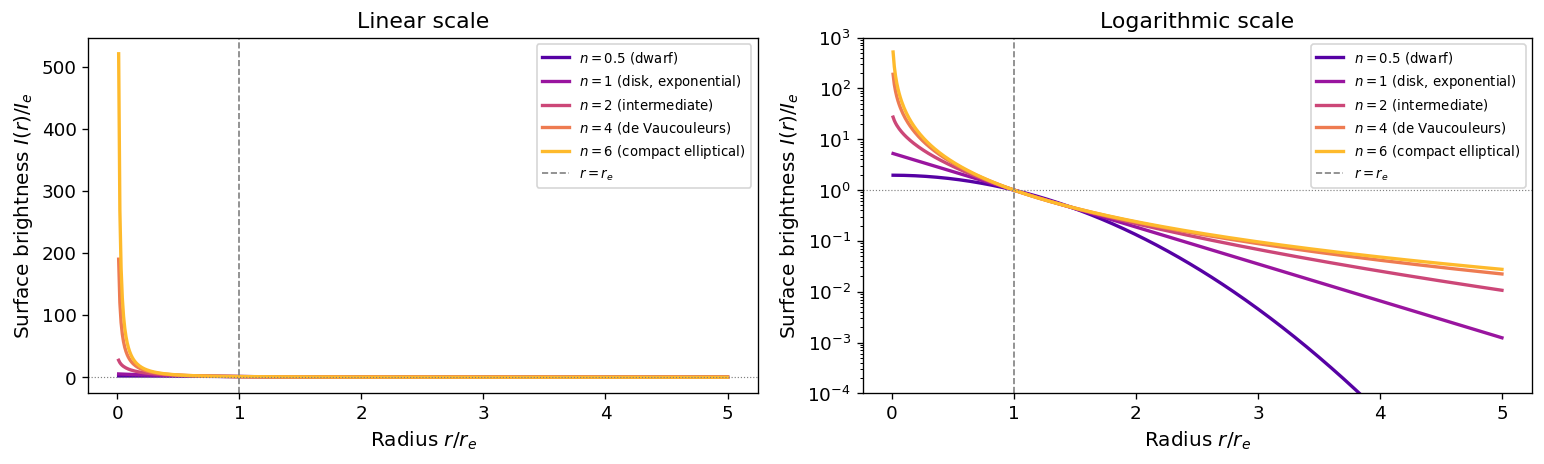

Observation: higher n → steeper inner profile and more extended wings.
At r = r_e, ALL profiles cross I = I_e by definition.


In [24]:
def b_n(n):
    """Approximation b_n ≈ 2n − 0.327 (Graham & Driver 2005).
    Accurate to ~1% for n ≥ 1; error grows to ~6% at n = 0.5.
    For n < 1 use: scipy.special.gammaincinv(2*n, 0.5)
    """
    return 2.0 * n - 0.327

def sersic_profile(r, n, r_e=1.0, I_e=1.0):
    """Sérsic profile I(r)."""
    bn = b_n(n)
    return I_e * np.exp(-bn * ((r / r_e)**(1.0 / n) - 1.0))

# ── Plot: Sérsic profiles for n = 0.5, 1, 2, 4, 6 ───────────────────────────
r = np.linspace(0.01, 5, 500)
n_values = [0.5, 1.0, 2.0, 4.0, 6.0]
labels   = [r'$n=0.5$ (dwarf)', r'$n=1$ (disk, exponential)',
            r'$n=2$ (intermediate)', r'$n=4$ (de Vaucouleurs)',
            r'$n=6$ (compact elliptical)']
colors   = plt.cm.plasma(np.linspace(0.15, 0.85, len(n_values)))

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

for ax in axes:
    for n_val, lbl, col in zip(n_values, labels, colors):
        profile = sersic_profile(r, n_val)
        ax.plot(r, profile, color=col, lw=2, label=lbl)
    ax.axvline(1.0, color='gray', lw=1, ls='--', label=r'$r = r_e$')
    ax.axhline(1.0, color='gray', lw=0.7, ls=':')
    ax.set_xlabel(r'Radius $r / r_e$')
    ax.set_ylabel(r'Surface brightness $I(r) / I_e$')
    ax.legend(fontsize=8)
    ax.set_title('Sérsic surface-brightness profiles')

axes[0].set_yscale('linear')
axes[0].set_title('Linear scale')
axes[1].set_yscale('log')
axes[1].set_ylim(1e-4, 1e3)
axes[1].set_title('Logarithmic scale')

plt.tight_layout()
plt.savefig('galsim_sersic_profiles.pdf', bbox_inches='tight')
plt.show()

print('Observation: higher n → steeper inner profile and more extended wings.')
print('At r = r_e, ALL profiles cross I = I_e by definition.')

---

## 8. Interactive Galaxy Image Explorer

Before diving into the automated pipeline, **play with this widget to build intuition** about all the concepts covered in sections 1–5:

- How do the Sérsic index $n$ and effective radius $r_e$ shape the 2D image?
- How does PSF blurring wash out fine structure — especially for small galaxies?
- What do *good* vs *poor* residuals look like?
- What happens when you start the fit far from the true parameters?

**Instructions:** Set galaxy parameters on the left → click **▶ Generate** → adjust the initial guess sliders in the middle → click **⚙ Fit** → read the fit quality statistics on the right.

> **Requires** the imports and parameters cells (sections 6–6.1) to have been run first.

In [26]:
# ================================================================
# Interactive Galaxy Image Explorer
# Section 8 -- ipywidgets, pure-numpy simulation, astropy fitting
#
# _simulate uses only numpy (numpy.fft Gaussian convolution +
# direct Sersic formula).  astropy.modeling.Sersic2D is used only
# in _fit, where it already works in the later pipeline sections.
#
# Requires: imports cell and params cell (section 6) already run.
# ================================================================
import io
import ipywidgets as widgets
from IPython.display import display, clear_output
from numpy.fft import fft2, ifft2, fftfreq

# -- Shared state ------------------------------------------------------------
_ws          = {}
_click_count = [0]
_STAMP_PX    = 81
_RN          = 5.0
_N_FREE      = 7

# -- Figure renderer (backend-agnostic) --------------------------------------
def _render(fig, dpi=110):
    buf = io.BytesIO()
    fig.savefig(buf, format='png', dpi=dpi, bbox_inches='tight')
    buf.seek(0)
    w = widgets.Image(value=buf.read(), format='png')
    plt.close(fig)
    return w

# -- Pure-numpy Sersic profile -----------------------------------------------
def _sersic_numpy(xx, yy, cx, cy, re_px, n, q, pa_rad, flux):
    # Sersic 2D via direct numpy formula; exponent clipped to prevent overflow
    dx  = xx.astype(np.float64) - float(cx)
    dy  = yy.astype(np.float64) - float(cy)
    cp  = float(np.cos(pa_rad))
    sp  = float(np.sin(pa_rad))
    xp  =  dx * cp + dy * sp
    yp  = -dx * sp + dy * cp
    r   = np.sqrt(xp**2 + (yp / max(float(q), 1e-3))**2)
    bn  = max(2.0 * float(n) - 0.327, 0.1)
    arg = -bn * ((r / max(float(re_px), 1e-3)) ** (1.0 / max(float(n), 0.05)) - 1.0)
    profile = np.exp(np.clip(arg, -50.0, 50.0))
    s = profile.sum()
    if s > 0:
        profile *= float(flux) / s
    return profile

# -- Gaussian PSF convolution via numpy.fft ----------------------------------
def _gauss_convolve(image, sigma_px):
    # Flux-conserving Gaussian blur using numpy FFT; always finite
    if float(sigma_px) < 0.05:
        return image.copy()
    ny, nx = image.shape
    fy     = fftfreq(ny)[:, None]
    fx     = fftfreq(nx)[None, :]
    kernel = np.exp(-2.0 * np.pi**2 * float(sigma_px)**2 * (fx**2 + fy**2))
    return np.real(ifft2(fft2(image) * kernel))

# -- Full simulation ---------------------------------------------------------
def _simulate(n_val, re_arcsec, flux_val, q_val, pa_deg,
              psf_fwhm_arcsec, sky_val, add_noise, seed):
    sz   = _STAMP_PX
    cx   = sz / 2.0
    yy_, xx_ = np.mgrid[0:sz, 0:sz]
    re_px    = max(float(re_arcsec) / PIXEL_SCALE, 0.5)
    psf_sig  = (float(psf_fwhm_arcsec) / PIXEL_SCALE) / (2.0 * np.sqrt(2.0 * np.log(2.0)))
    sky_f    = float(sky_val)
    profile  = _sersic_numpy(xx_, yy_, cx, cx, re_px, n_val, q_val,
                               np.deg2rad(float(pa_deg)), float(flux_val))
    conv     = _gauss_convolve(profile, psf_sig)
    s = conv.sum()
    if s > 0:
        conv *= float(flux_val) / s
    if add_noise:
        rng_  = np.random.default_rng(int(seed))
        lam   = np.maximum(conv + sky_f, 0.0)
        noisy = rng_.poisson(lam).astype(np.float64) - sky_f
        noisy += rng_.normal(0.0, _RN, noisy.shape)
    else:
        noisy = conv.copy()
    sigma = np.sqrt(np.abs(noisy) + sky_f + _RN**2).clip(1e-3)
    return conv, noisy, sigma

# ============================================================================
# Widget controls
# ============================================================================
W = lambda px=275: widgets.Layout(width=f'{px}px')

w_profile = widgets.Dropdown(
    options=[('Disk  (n = 1)', 1.0), ('Elliptical  (n = 4)', 4.0), ('Custom n', None)],
    value=1.0, description='Profile:',
    style={'description_width': '58px'}, layout=W(265))

w_n_cust = widgets.BoundedFloatText(
    value=1.0, min=0.3, max=6.0, step=0.1, description='n:',
    style={'description_width': '22px'}, layout=W(105), disabled=True)

w_re = widgets.FloatSlider(
    min=0.4, max=3.0, step=0.1, value=0.8, description='r_e ["]',
    readout_format='.1f', style={'description_width': '55px'}, layout=W(285))

w_flux = widgets.FloatLogSlider(
    min=2.5, max=4.0, step=0.05, value=3.5, base=10,
    description='flux',     readout_format='.0f',
    style={'description_width': '60px'}, layout=W(285))

w_q = widgets.FloatSlider(
    min=0.3, max=1.0, step=0.05, value=0.7, description='q (b/a)',
    readout_format='.2f', style={'description_width': '60px'}, layout=W(285))

w_pa = widgets.FloatSlider(
    min=0, max=175, step=5, value=45, description='PA [deg]',
    readout_format='.0f', style={'description_width': '55px'}, layout=W(285))

w_psf = widgets.FloatSlider(
    min=0.4, max=2.0, step=0.1, value=0.8, description='PSF ["]',
    readout_format='.1f', style={'description_width': '55px'}, layout=W(285))

w_sky = widgets.IntSlider(
    min=50, max=500, step=50, value=200, description='Sky',
    style={'description_width': '35px'}, layout=W(285))

w_noise = widgets.Checkbox(value=True, description='Add noise', layout=W(120))

btn_gen = widgets.Button(description='Generate', button_style='success',
    layout=widgets.Layout(width='120px', height='32px'))

w_n_fit = widgets.FloatSlider(
    min=0.3, max=6.0, step=0.1, value=1.0, description='n0',
    readout_format='.1f', style={'description_width': '30px'}, layout=W(285))

w_re_fit = widgets.FloatSlider(
    min=0.1, max=3.0, step=0.1, value=0.8, description='r_e0 ["]',
    readout_format='.1f', style={'description_width': '60px'}, layout=W(285))

w_fix_n  = widgets.Checkbox(value=False, description='fix n',  layout=W(95))
w_fix_re = widgets.Checkbox(value=False, description='fix r_e', layout=W(95))

btn_fit = widgets.Button(description='Fit', button_style='primary',
    layout=widgets.Layout(width='115px', height='32px'), disabled=True)

out_gen   = widgets.Output(layout=widgets.Layout(width='305px', min_height='240px'))
out_model = widgets.Output(layout=widgets.Layout(width='305px', min_height='240px'))
out_resid = widgets.Output(layout=widgets.Layout(width='305px', min_height='240px'))
stats_html = widgets.HTML(
    value='<div style="color:#999;font-style:italic;padding:6px">Generate an image, then click Fit</div>')

# ============================================================================
# Callbacks
# ============================================================================

def _generate(btn):
    try:
        _click_count[0] += 1
        n_val    = w_profile.value if w_profile.value is not None else float(w_n_cust.value)
        re_val   = float(w_re.value)
        flux_val = float(w_flux.value)
        sky_val  = float(w_sky.value)
        snr = flux_val / np.sqrt(flux_val + _STAMP_PX**2 * sky_val + _STAMP_PX**2 * _RN**2)

        _, arr_noisy, sigma_map = _simulate(
            n_val, re_val, flux_val, float(w_q.value),
            float(w_pa.value), float(w_psf.value),
            sky_val, bool(w_noise.value), _click_count[0])

        _ws.update(image=arr_noisy, sigma=sigma_map, n_true=n_val, re_true=re_val)
        # Do NOT auto-reset fit sliders: the student sets the initial guess manually.

        fig, ax = plt.subplots(figsize=(3.0, 2.8))
        vmax = max(float(np.percentile(arr_noisy, 99.5)), 1.0)
        ax.imshow(arr_noisy, origin='lower', cmap='inferno', vmin=-0.03*vmax, vmax=vmax)
        ax.add_patch(plt.Circle((_STAMP_PX//2, _STAMP_PX//2), re_val/PIXEL_SCALE,
                                color='cyan', fill=False, lw=1.2, ls='--'))
        ax.set_title(f'n={n_val:.1f}  r_e={re_val:.1f}"  q={w_q.value:.2f}\n'
                     f'PSF={w_psf.value:.1f}"  SNR~{snr:.0f}', fontsize=8)
        ax.set_xlabel('x [px]', fontsize=8); ax.set_ylabel('y [px]', fontsize=8)
        plt.tight_layout()
        with out_gen:
            clear_output(wait=True); display(_render(fig))
        with out_model: clear_output(wait=True)
        with out_resid: clear_output(wait=True)
        stats_html.value = ('<div style="color:#999;font-style:italic;padding:6px">'
                            'Click Fit to fit a Sersic model</div>')
        btn_fit.disabled = False

    except Exception as e:
        import traceback as _tb
        tb_str = _tb.format_exc()
        with out_gen:
            clear_output(wait=True)
            display(widgets.HTML(
                f'<div style="color:red;padding:6px"><b>Error in Generate:</b><br>'
                f'<code>{type(e).__name__}: {e}</code><br>'
                f'<pre style="font-size:10px">{tb_str}</pre>'
                f'</div>'))


def _fit(btn):
    if not _ws:
        return
    try:
        arr, sigma = _ws['image'], _ws['sigma']
        sz   = arr.shape[0]; cx = sz / 2.0
        yy_, xx_ = np.mgrid[0:sz, 0:sz]
        n0    = float(w_n_fit.value)
        re0px = float(w_re_fit.value) / PIXEL_SCALE
        eps   = 1e-4
        import math as _math
        bounds = {
            'ellip':     (0.0, 0.95),
            'amplitude': (0.0, None),
            'theta':     (-_math.pi / 2.0, _math.pi / 2.0),   # break π-symmetry
            'n':     (n0 - eps, n0 + eps) if w_fix_n.value  else (0.3, 6.0),
            'r_eff': (re0px*(1-eps), re0px*(1+eps)) if w_fix_re.value else (0.3, sz*0.45),
        }
        m0 = models.Sersic2D(amplitude=max(float(arr.max()), 1.0),
                              r_eff=re0px, n=n0, x_0=cx, y_0=cx,
                              ellip=0.3, theta=0.0, bounds=bounds)
        fitter_lm = fitting.LevMarLSQFitter()
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            m_fit = fitter_lm(m0, xx_, yy_, arr, weights=1.0/sigma, maxiter=500)

        model_arr = m_fit(xx_, yy_)
        resid_arr = arr - model_arr
        n_fit   = m_fit.n.value
        re_fit  = m_fit.r_eff.value * PIXEL_SCALE
        n_true  = _ws.get('n_true', float('nan'))
        re_true = _ws.get('re_true', float('nan'))

        # ── Galaxy mask: pixels where the model contributes significantly ──────
        # Using ALL pixels dilutes chi2 and frac_1s with noise-dominated background
        # pixels that are always ~68% within 1-sigma regardless of the fit quality.
        thresh   = max(float(model_arr.max()) * 0.05, 1e-10)
        gal_mask = model_arr > thresh
        n_gal    = int(gal_mask.sum())
        if n_gal < max(_N_FREE + 1, 20):
            gal_mask = np.ones((sz, sz), dtype=bool)
            n_gal    = sz * sz

        r_gal   = resid_arr[gal_mask]
        s_gal   = sigma[gal_mask]
        dof_gal = max(n_gal - _N_FREE, 1)

        chi2_dof  = float(np.sum((r_gal / s_gal)**2) / dof_gal)
        r_mean    = float(np.mean(r_gal))
        r_std     = float(np.std(r_gal))
        frac_1s   = float(np.mean(np.abs(r_gal) < s_gal))
        max_nsig  = float(np.max(np.abs(r_gal) / np.clip(s_gal, 1e-6, None)))
        med_sig   = float(np.median(s_gal))

        def _c(ok): return 'green' if ok else '#cc4400'
        stats_html.value = (
            '<div style="padding:5px;font-size:11.5px;line-height:1.8">'
            f'<span style="font-size:10px;color:#888">galaxy region: {n_gal} px</span>'
            '<br><b>Fit quality</b><table>'
            f'<tr><td>chi2/dof</td><td><b>{chi2_dof:.3f}</b></td>'
            f'<td style="color:{_c(0.3<chi2_dof<2.0)}">{("good" if 0.3<chi2_dof<2.0 else "poor")}</td></tr>'
            f'<tr><td>max |r|/sigma</td><td><b>{max_nsig:.1f}</b></td>'
            f'<td style="color:{_c(max_nsig<4.0)}">{("ok" if max_nsig<4.0 else "outlier")}</td></tr>'
            f'<tr><td>Resid mean</td><td><b>{r_mean:+.2f}</b></td>'
            f'<td style="color:{_c(abs(r_mean)<r_std)}">{("unbiased" if abs(r_mean)<r_std else "biased")}</td></tr>'
            f'<tr><td>Pix in 1s</td><td><b>{frac_1s*100:.0f}%</b></td>'
            f'<td style="color:{_c(frac_1s>0.55)}">{("~68% ok" if frac_1s>0.55 else "outliers")}</td></tr>'
            '</table><hr style="margin:3px 0"><b>Parameters</b><table>'
            f'<tr><td>n</td><td>in <b>{n_true:.2f}</b></td>'
            f'<td>-> fit <b style="color:{_c(abs(n_fit-n_true)<0.3)}">{n_fit:.2f}</b></td></tr>'
            f'<tr><td>r_e["]</td><td>in <b>{re_true:.2f}</b></td>'
            f'<td>-> fit <b style="color:{_c(abs(re_fit-re_true)<0.15)}">{re_fit:.2f}</b></td></tr>'
            '</table></div>')

        vmax = max(float(np.percentile(arr, 99.5)), 1.0)
        v    = max(float(np.percentile(np.abs(resid_arr), 97)), 1.0)

        fig2, ax2 = plt.subplots(figsize=(3.0, 2.8))
        ax2.imshow(model_arr, origin='lower', cmap='inferno', vmin=-0.03*vmax, vmax=vmax)
        ax2.set_title(f'Fit: n={n_fit:.2f}  r_e={re_fit:.2f}"', fontsize=8)
        ax2.set_xlabel('x [px]', fontsize=8); ax2.set_ylabel('y [px]', fontsize=8)
        plt.tight_layout()
        with out_model: clear_output(wait=True); display(_render(fig2))

        fig3, ax3 = plt.subplots(figsize=(3.0, 2.8))
        im3 = ax3.imshow(resid_arr, origin='lower', cmap='RdBu_r', vmin=-v, vmax=v)
        plt.colorbar(im3, ax=ax3, fraction=0.046, pad=0.04)
        ax3.set_title(f'Residuals (chi2/dof={chi2_dof:.2f})', fontsize=8)
        ax3.set_xlabel('x [px]', fontsize=8); ax3.set_ylabel('y [px]', fontsize=8)
        plt.tight_layout()
        with out_resid: clear_output(wait=True); display(_render(fig3))

    except Exception as e:
        with out_resid:
            clear_output(wait=True)
            display(widgets.HTML(
                f'<div style="color:red;padding:6px"><b>Error in Fit:</b><br>'
                f'<code>{type(e).__name__}: {e}</code></div>'))


def _on_profile_change(change):
    preset = change['new']
    w_n_cust.disabled = preset is not None
    if preset is not None: w_n_cust.value = preset

btn_gen.on_click(_generate)
btn_fit.on_click(_fit)
w_profile.observe(_on_profile_change, names='value')

# ============================================================================
# Layout
# ============================================================================
_box = dict(border='1px solid #d0d0d0', padding='8px',
            border_radius='6px', min_width='305px')

col_gen = widgets.VBox([
    widgets.HTML('<b>1. Galaxy Parameters</b>'),
    widgets.HBox([w_profile, w_n_cust]),
    w_re, w_flux, w_q, w_pa,
    widgets.HTML('<b>Observation</b>'),
    w_psf, w_sky,
    widgets.HBox([w_noise, btn_gen]),
], layout=widgets.Layout(**_box))

col_fit = widgets.VBox([
    widgets.HTML('<b>2. Fitting -- Initial Guess</b>'),
    widgets.HTML('<span style="font-size:11px;color:#666">'
                 'Sliders set the optimizer starting point.<br>'
                 'Mis-set them to explore convergence failures.</span>'),
    w_n_fit, w_re_fit,
    widgets.HTML('<b>Freeze during fit:</b>'),
    widgets.HBox([w_fix_n, w_fix_re]),
    btn_fit,
], layout=widgets.Layout(**_box))

col_stats = widgets.VBox([
    widgets.HTML('<b>3. Fit Quality</b>'),
    widgets.HTML('<span style="font-size:11px;color:#666">'
                 'chi2/dof~1: noise-consistent<br>'
                 'chi2/dof>>1: model mismatch<br>'
                 'chi2/dof<<1: noise over-estimated</span>'),
    stats_html,
], layout=widgets.Layout(**_box))

display(widgets.VBox([
    widgets.HTML('<h4 style="margin:4px 0">Galaxy Image Explorer</h4>'
                 '<p style="margin:0;font-size:12px;color:#555">'
                 'Cyan circle = r_e. Good residuals look like white noise.</p>'),
    widgets.HBox([col_gen, col_fit, col_stats],
                 layout=widgets.Layout(align_items='flex-start', gap='8px')),
    widgets.HBox([out_gen, out_model, out_resid],
                 layout=widgets.Layout(align_items='flex-start', gap='6px')),
]))


---

## Next steps

This notebook covered the **theory** (sections 1–5) and gave you an **interactive explorer** (section 8) to build intuition about Sérsic profiles, PSF blurring, and profile fitting.

**Continue in `galaxy_image_simulation_part2.ipynb`**, which covers:
- Section 9: Simulating a single galaxy step-by-step
- Section 10: Simulating a 30-galaxy field
- Section 11: Source detection with photutils
- Section 12: Sérsic profile fitting
- Sections 13–15: Input/output comparison, SNR dependence, PSF effect
